# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 3. Генеративные модели.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

## Warning: домашнее задание несколько муторное, потому что требуется обучить 4 типа моделей. Но в то же время оно простое, поэтому проблем с написанием кода возникнуть не должно.

# Введение

## MAGIC – Major Atmospheric Gamma Imaging Cherenkov Telescope

MAGIC (Major Atmospheric Gamma Imaging Cherenkov) - это система, состоящая из двух черенковских телескопов диаметром 17 м. Они предназначены для наблюдения гамма-лучей от галактических и внегалактических источников в диапазоне очень высоких энергий (от 30 ГэВ до 100 ТэВ).

Телескопами MAGIC в настоящее время управляют около 165 астрофизиков из 24 организаций и консорциумов из 12 стран. MAGIC позволил открыть и исследовать новые классы источников гамма-излучения, таких как, например, пульсары и гамма-всплески (GRB).

<center><img src="img/magic1.jpg" width="1000"></center>

Источник: https://magic.mpp.mpg.de/

Youtube video: https://youtu.be/mjcDSR2vSU8

## Частицы из космоса

Космические частицы, $\gamma$-кванты (фотоны) и адроны (протоны), взаимодействуют с атмосферой и порождают ливни вторичных частиц. Двигаясь с околосветовой скоростью, эти частицы излучают Черенковское излучение. Телескопы фотографируют это излучение. По фотографиям можно определить тип частицы из космоса: фотон или протон.

<center><img src="img/shower.jpg" width="500"></center>

## Фотографии

Задача атмосферного черенковского телескопа - получить изображение ливня путем измерения черенковского света от частиц ливня. Это изображение представляет собой геометрическую проекцию ливня на детектор. Для анализа этих изображений были введены параметры изображения или так называемые параметры Хилласа. Есть два вида параметров изображения: параметры формы и параметры ориентации. (Источник: http://ihp-lx.ethz.ch/Stamet/magic/parameters.html)

<center><img src="img/geo.jpg" width="400"></center>

## Фотоны vs адронов

Изображения для $\gamma$-квантов (фотонов) и адронов (протонов) отличаются по форме кластеров. Астрономы используют модели машинного обучения для классификации этих изображений. Для обучения моделей ученые искусственно генерируют такие изображения для каждого типа частиц с помощью сложных физических симуляторов.


<center><img src="img/gamma_p.png" width="600"></center>

## Ускорение симуляции

Сложные физические симуляторы требуют больших вычислительных ресурсов. Они моделируют прилет частиц из космоса, их взаимодействие с атмосферой, рождение ливней, черенковского излучения и работы телескопов для получения изображений. Но мы можем использовать генеративно-состязательные сети для быстрой симуляции!

In [56]:
!pip install diffusers


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [57]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
# diffusers импортируется в ячейке с DiffusionFitter — меньше нагрузка на ядро при Run All
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

In [58]:
# Устойчивое сохранение артефактов для восстановления после падения Colab. Сервисная ячейка.

# В Cursor ставим False - тяжёлые блоки (fit, generate_with_diffusion) не запускаются. В Colab поставь True.
RUN_HEAVY = False

# Безопасный режим - быстрый прогон для проверки работоспособности (потом можно увеличить)
WGAN_EPOCHS = 20
WGAN_BATCH = 128
WGAN_N_CRITIC = 3

CVAE_EPOCHS = 20
CVAE_BATCH = 128

DIFF_EPOCHS = 3
DIFF_INFER_STEPS = 250

from pathlib import Path
import json
import numpy as np
import torch

# Прогрев CUDA - чтобы не ловить предупреждения и лаги на первом backward
def warmup_cuda():
    if torch.cuda.is_available():
        _ = torch.randn(1, device="cuda") @ torch.randn(1, device="cuda")
        torch.cuda.synchronize()

ART_DIR = Path("artifacts_hw3")
ART_DIR.mkdir(parents=True, exist_ok=True)


def save_np(path, arr):
    """Сохранение массива в .npy."""
    if arr is None:
        return
    try:
        np.save(path, arr)
    except Exception as e:
        print(f"save_np: ошибка - {e}")


def save_json(path, data):
    """Сохранение словаря в .json."""
    if data is None or not data:
        return
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
    except Exception as e:
        print(f"save_json: ошибка - {e}")


def save_torch(path, obj):
    """Сохранение объекта в .pt (state_dict или тензор)."""
    if obj is None:
        return
    try:
        torch.save(obj, path)
    except Exception as e:
        print(f"save_torch: ошибка - {e}")


def load_torch(path, device=None):
    """Загрузка из .pt. Если файла нет - возвращает None."""
    try:
        return torch.load(path, map_location=device or "cpu")
    except FileNotFoundError:
        return None
    except Exception as e:
        print(f"load_torch: ошибка - {e}")
        return None


def safe_save(prefix, models=None, arrays=None, metrics=None, extra=None):
    """
    Сохраняет артефакты в ART_DIR/prefix:
    - models: словарь {имя: модель} -> .pt (state_dict)
    - arrays: словарь {имя: массив} -> .npy
    - metrics и extra -> results.json
    """
    if not prefix or not isinstance(prefix, str):
        print("safe_save: prefix должен быть непустой строкой")
        return

    root = ART_DIR / prefix
    try:
        root.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        print(f"safe_save: не удалось создать папку {root} - {e}")
        return

    saved = []

    if models:
        for name, model in models.items():
            if model is None:
                continue
            try:
                p = root / f"{name}.pt"
                state = model.state_dict() if hasattr(model, "state_dict") else model
                torch.save(state, p)
                saved.append(str(p))
            except Exception as e:
                print(f"safe_save: модель {name} - {e}")

    if arrays:
        for name, arr in arrays.items():
            if arr is None:
                continue
            try:
                p = root / f"{name}.npy"
                np.save(p, arr)
                saved.append(str(p))
            except Exception as e:
                print(f"safe_save: массив {name} - {e}")

    results = {}
    if metrics:
        results["metrics"] = {
            k: (float(v) if isinstance(v, (int, float)) else v)
            for k, v in metrics.items()
        }

    if extra:
        def _serialize(v):
            if isinstance(v, (int, float, str, bool, type(None))):
                return v
            if isinstance(v, (list, tuple)):
                return [_serialize(x) for x in v]
            if isinstance(v, dict):
                return {k: _serialize(x) for k, x in v.items()}
            return str(v)

        results["extra"] = {k: _serialize(v) for k, v in extra.items()}

    if results:
        try:
            p = root / "results.json"
            with open(p, "w", encoding="utf-8") as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
            saved.append(str(p))
        except Exception as e:
            print(f"safe_save: results.json - {e}")

    if saved:
        print("saved:", ", ".join(saved))
    else:
        print("safe_save: нечего сохранять или всё упало")


def safe_load_model(prefix, name, model, device=None):
    """
    Загружает state_dict из ART_DIR/prefix/{name}.pt в model и переводит в eval().
    Если файла нет - печатает сообщение и не падает.
    """
    if not prefix or not name or model is None:
        print("safe_load_model: нужны prefix, name и модель")
        return

    path = ART_DIR / prefix / f"{name}.pt"
    if not path.exists():
        print(f"safe_load_model: файла нет - {path}")
        return

    try:
        state = torch.load(path, map_location=device or "cpu")
        model.load_state_dict(state)
        if device is not None:
            model.to(device)
        model.eval()
        print(f"safe_load_model: загружено {path}")
    except Exception as e:
        print(f"safe_load_model: ошибка - {e}")


# Итог ячейки:
# - Что сделала: задала ART_DIR и функции save_np, save_json, save_torch, load_torch, safe_save, safe_load_model для сохранения и загрузки артефактов без падения ноутбука.
# - Что получилось: можно вызывать safe_save("wgan", models={...}, arrays={...}, metrics={...}) и safe_load_model("wgan", "generator", model, device) после импортов.

# Данные

Будем использовать данные телескопа MAGIC из UCI репозитория https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope. Каждый объект в данных - параметры одного изображения кластера и метка этого кластера (фотон или адрон):


0. Length: major axis of ellipse [mm]
1. Width: minor axis of ellipse [mm]
2. Size: 10-log of sum of content of all pixels [in #phot]
3. Conc: ratio of sum of two highest pixels over fSize [ratio]
4. Conc1: ratio of highest pixel over fSize [ratio]
5. Asym: distance from highest pixel to center, projected onto major axis [mm]
6. M3Long: 3rd root of third moment along major axis [mm]
7. M3Trans: 3rd root of third moment along minor axis [mm]
8. Alpha: angle of major axis with vector to origin [deg]
9. Dist: distance from origin to center of ellipse [mm]
10. class: g,h # gamma (signal), hadron (background)

In [59]:
# read data
names = np.array(
    [
        "Length",
        "Width",
        "Size",
        "Conc",
        "Conc1",
        "Asym",
        "M3Long",
        "M3Trans",
        "Alpha",
        "Dist",
        "class",
    ]
)
data = pd.read_csv("magic04.data", header=None)
data.columns = names
data.head()

,Length,Width,Size,Conc,Conc1,Asym,M3Long,M3Trans,Alpha,Dist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


# Постановка задачи

Ваша задача заключается в том, чтобы с помощью генеративно-состязательных сетей научится генерировать параметры кластеров на изображениях телекопа для каждого типа частиц (фотона или адрона):

- $X$ - матрица реальных объектов, которые нужно начиться генерировать;
- $y$ - метки классов, которые будем использовать как условие при генерации.

In [60]:
# параметры кластеров на изображениях
X = data[names[:-1]].values
X = np.abs(X)

# метки классов
labels = data[names[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [61]:
# примеры
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [62]:
# примеры
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

# Визуализация данных

Каждое изображение описывается 10 параметрами. Давайте построим распределения значений каждого параметра для каждого типа частиц.

In [63]:
def plot_hists(X1, X2, names, label1, label2, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(4 * 4, 4 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.hist(X1[:, i], bins=bins, alpha=0.5, label=label1, color="C0")
        plt.hist(X2[:, i], bins=bins, alpha=0.5, label=label2, color="C1")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

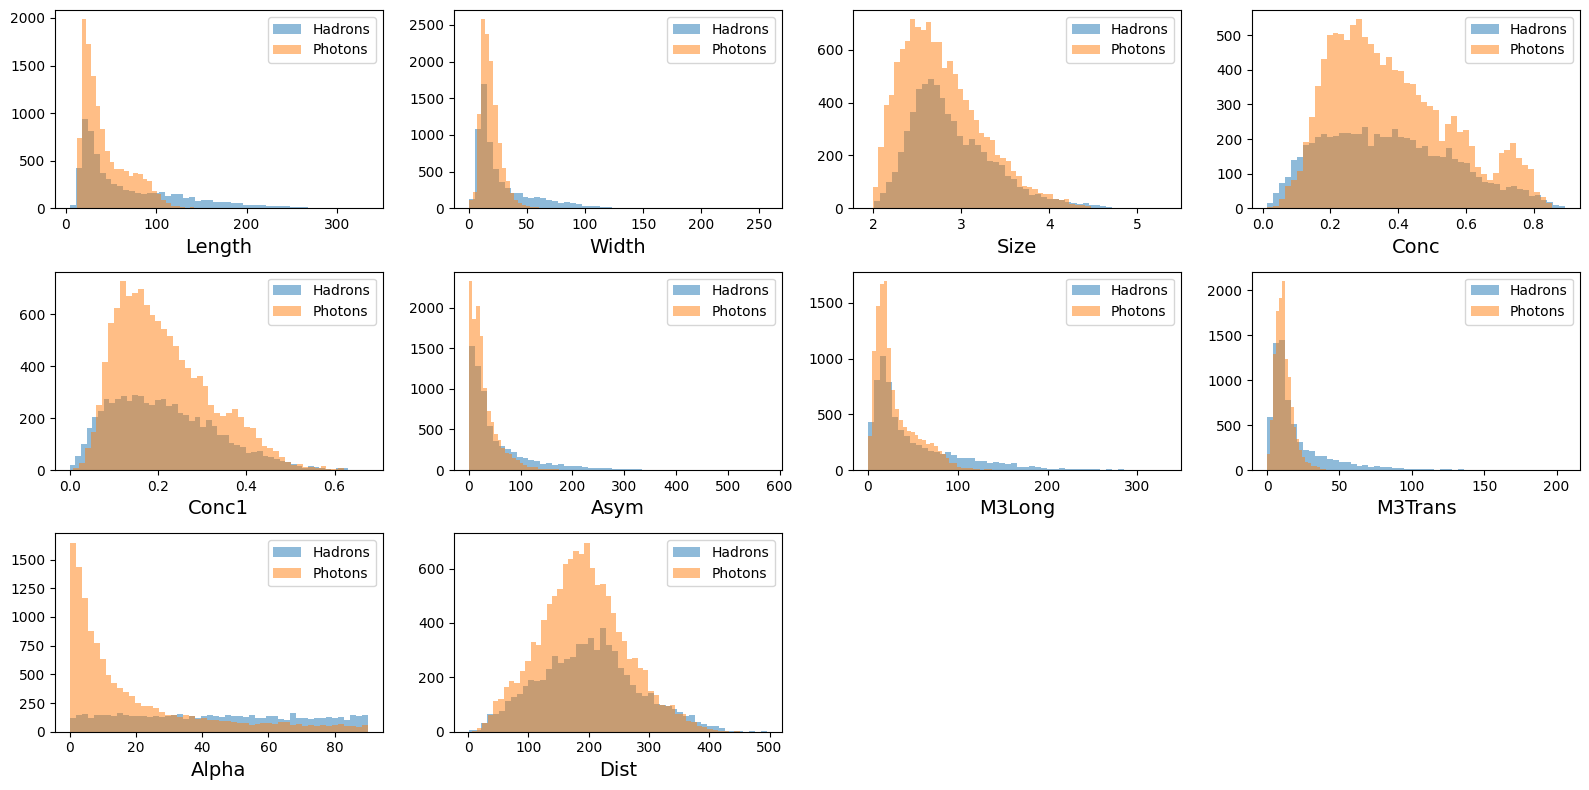

In [64]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

# Предобработка данных

Из графика видим, что распределения для многих признаков имеют тяжелые хвосты. Это делает обучение генеративных моделей тяжелее. Поэтому, нужно как-то преобразовать данные, чтобы убрать эти тяжелые хвосты.

## Задание 1 (0.5 балла)

Используя функцию `sklearn.preprocessing.QuantileTransformer` трансформируйте входные данные `X`. Это преобразование делает так, чтобы распределение каждого параметра было нормальным. Описание функции доступно по ссылке http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html. Используйте значение параметра `output_distribution='normal'`.

In [65]:
### YOUR CODE IS HERE ######
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_qt = qt.fit_transform(X)

### THE END OF YOUR CODE ###

Комментарий: Перед обучением генеративных моделей мы приводим данные к удобному распределению.
Аналогично семинарам по GAN и Autoencoders, где используется нормализация признаков, здесь применяется QuantileTransformer с output_distribution='normal', чтобы приблизить распределения признаков к гауссовым.

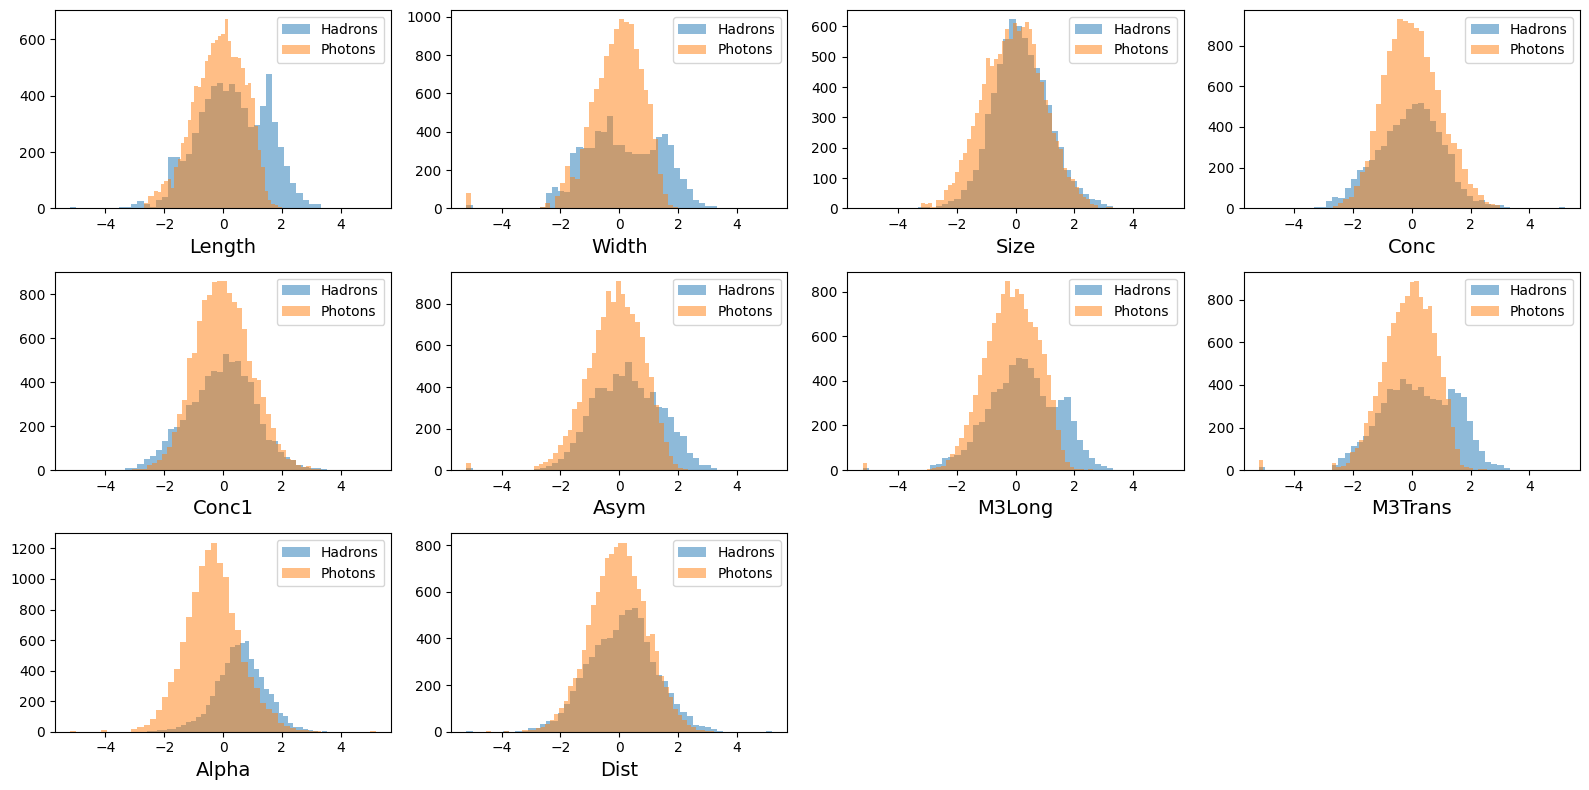

In [66]:
plot_hists(
    X_qt[y[:, 0] == 0],
    X_qt[y[:, 0] == 1],
    names,
    label1="Hadrons",
    label2="Photons",
    bins=50,
)

# Обучающая и тестовая выборки

In [67]:
# Разбиение на обучающую и проверочную выборки (в пространстве qt).
X_train, X_test, y_train, y_test = train_test_split(
    X_qt, y, stratify=y, test_size=0.5, shuffle=True, random_state=11
)
# Реальные объекты в исходной шкале - для сравнения и ROC после inverse_transform сгенерированных.
# [Семинар 08: 08_GANs.ipynb]
X_train_orig, X_test_orig, _, _ = train_test_split(
    X, y, stratify=y, test_size=0.5, shuffle=True, random_state=11
)

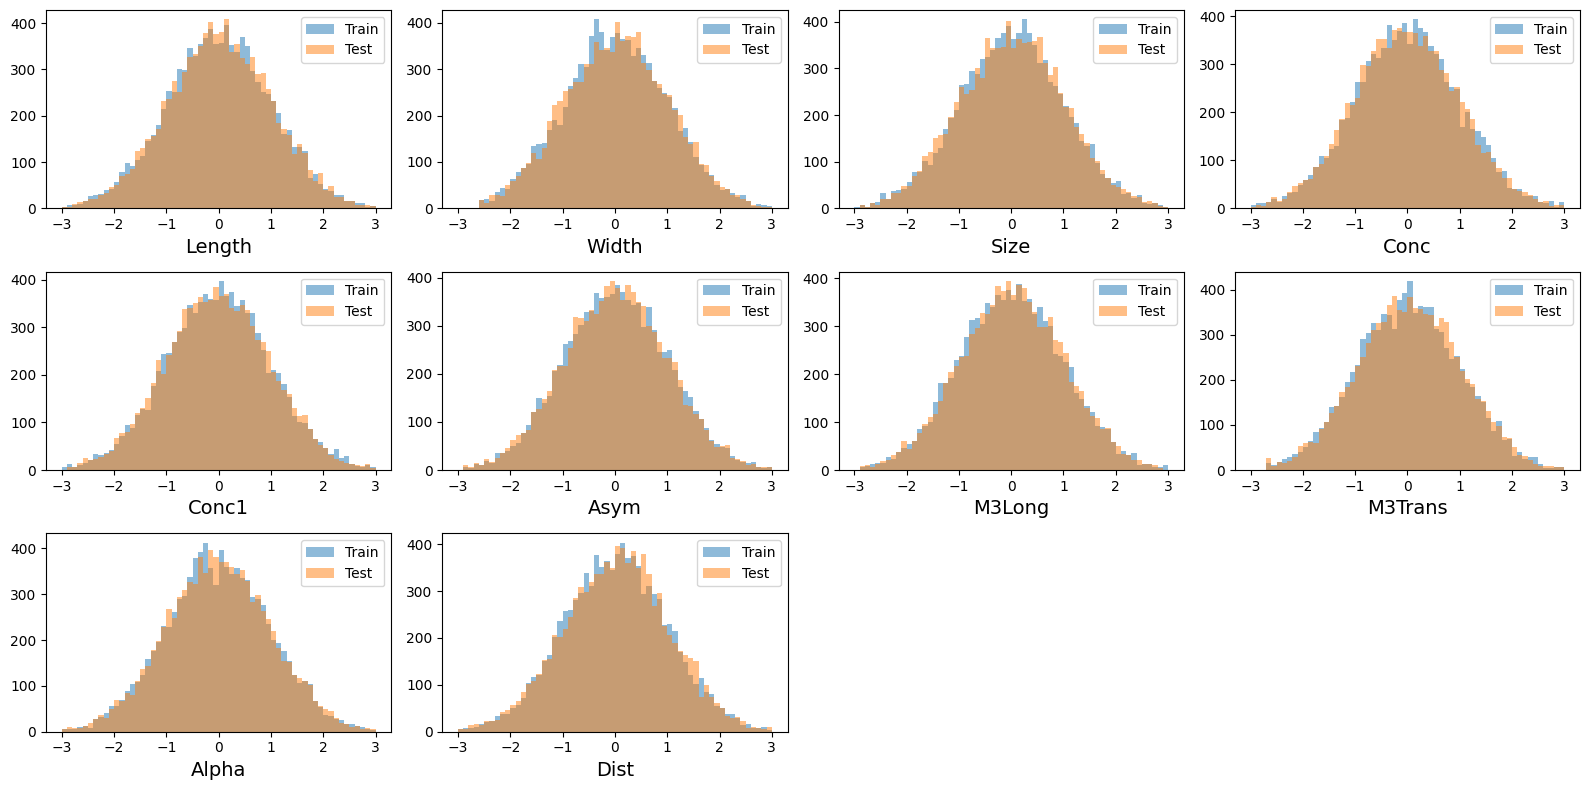

In [68]:
plot_hists(X_train, X_test, names, label1="Train", label2="Test")

# Conditional WGAN

Мы будем использовать `Conditional WGAN`, который изображен на рисунке. В качестве условия `y` мы будем использовать метку класса: **0** - адрон, **1** - фотон. Таким образом, мы будем сообщать генератору для какой частицы нужно генерировать параметры изображения.

<center><img src="img/cgan.png" width="800"></center>

Генератор $\hat{x} = G(z, y)$ будет принимать на вход шумовой вектор $z$ и вектор условий $y$, а выдавать будет сгенерированный (фейковый) вектор параметров $\hat{x}$.

Дискриминатор $D(x, y)$ будет принимать на вход вектор параметров $x$ и вектор условий $y$, а возвращать будет рациональное число.

Обучать `Conditional WGAN` будем с такой функцией потерь:

$$L(G, D) = -\frac{1}{n} \sum_{x_i \in X, y_i \in y} D(x_i, y_i) + \frac{1}{n} \sum_{z_i \in Z, y_i \in y} D(G(z_i, y_i), y_i) \to \max_G \min_D$$

In [69]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [70]:
DEVICE

device(type='cpu')

## Задание 2 (0.25 балла)

Реализуйте нейронную сеть для генератора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [71]:
class Generator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs),
        )
        ### THE END OF YOUR CODE ###

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)


Комментарий: реализация conditional генератора для WGAN
Формирую вход: zy = concat(z, y), чтобы сеть знала, какой класс генерировать (hadron/photon). Использую 2 полносвязных слоя по 100 нейронов с BatchNorm и ReLU для стабильного обучения (беру порядок из семинаров: Linear - BN - ReLU).
Выходной слой возвращает вектор из n_outputs=10 признаков (без активации, тк значения могут быть любыми)


## Задание 3 (0.25 балла)

Реализуйте нейронную сеть для дискриминатора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [72]:
class Discriminator(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )
        ### THE END OF YOUR CODE ###

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        return self.net(xy)

Комментарий: Conditional дискриминатор для WGAN. Вход: признаки объекта x (10) и условие y (0/1), конкатенированные по признакам. Архитектура: два полносвязных слоя с ReLU, выходной слой возвращает скаляр без активации,
так как в WGAN критик оценивает близость распределений, а не вероятность real/fake.


## Задание 4 (1 балл)

Реализуйте класс для обучения генеративной модели.

- Подсказка 1: не забывайте ограничивать веса дискриминатора. Для этого используйте `p.data.clamp_(-0.01, 0.01)`, где `p` веса дискриминатора.
- Подсказка 2: `n_critic` - число итераций обучения дискриминатора на одну итерацию обучения генератора.
- Подсказка 3: Используйте `X_tensor = torch.tensor(X_numpy, dtype=torch.float, device=DEVICE)` для перевода numpy в тензор.

In [73]:
# Штраф на градиент для WGAN-GP: ограничиваем липшицевость критика без клиппинга весов.
# [Семинар 08: 08_GANs.ipynb]
def compute_gradient_penalty(discriminator, real_batch, fake_batch, cond_batch):
    batch_size = real_batch.size(0)
    alpha = torch.rand(batch_size, 1, device=real_batch.device).expand_as(real_batch)
    interpolated = (alpha * real_batch + (1 - alpha) * fake_batch.detach()).requires_grad_(True)
    d_interp = discriminator(interpolated, cond_batch)
    grad_outputs = torch.ones_like(d_interp)
    gradients = torch.autograd.grad(
        outputs=d_interp, inputs=interpolated, grad_outputs=grad_outputs,
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp

# Коэффициент штрафа на градиент (WGAN-GP). [Семинар 08: 08_GANs.ipynb]
LAMBDA_GP = 10

class Fitter(object):
    def __init__(
        self,
        generator,
        discriminator,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):
        self.generator = generator
        self.discriminator = discriminator
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic
        self.loss_history = []

        self.opt_gen = torch.optim.RMSprop(self.generator.parameters(), lr=self.lr)
        self.opt_disc = torch.optim.RMSprop(self.discriminator.parameters(), lr=self.lr)

        self.generator.to(DEVICE)
        self.discriminator.to(DEVICE)

    def fit(self, X, y):
        # из нампи в тензор
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # y должен быть (N, 1), чтобы корректно конкатенировать с x/z
        if y_cond.dim() == 1:
            y_cond = y_cond.view(-1, 1)

        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.generator.train(True)
        self.discriminator.train(True)

        self.loss_history = []

        # Fit GAN
        for epoch in range(self.n_epochs):
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):
                # гарантируем тип/форму условия
                cond_batch = cond_batch.float()
                if cond_batch.dim() == 1:
                    cond_batch = cond_batch.view(-1, 1)

                #Обучаем дискриминатор  n_critic раз
                for _ in range(self.n_critic):
                    # 1) шум
                    z = torch.normal(
                        0, 1,
                        (real_batch.size(0), self.latent_dim),
                        device=DEVICE
                    )

                    # 2) фейки
                    fake_batch = self.generator(z, cond_batch)

                    # 3) оценки критика
                    d_real = torch.mean(self.discriminator(real_batch, cond_batch))
                    d_fake = torch.mean(self.discriminator(fake_batch.detach(), cond_batch))

                    # 4) функция потерь критика: WGAN + штраф на градиент (WGAN-GP). [Семинар 08: 08_GANs.ipynb]
                    gp = compute_gradient_penalty(self.discriminator, real_batch, fake_batch.detach(), cond_batch)
                    loss_disc = -(d_real - d_fake) + LAMBDA_GP * gp

                    self.opt_disc.zero_grad()
                    loss_disc.backward()
                    self.opt_disc.step()

                # 2 Обучаем генератор один раз
                z = torch.normal(
                    0, 1,
                    (real_batch.size(0), self.latent_dim),
                    device=DEVICE
                )
                fake_batch = self.generator(z, cond_batch)

                d_fake = torch.mean(self.discriminator(fake_batch, cond_batch))
                loss_gen = -d_fake

                self.opt_gen.zero_grad()
                loss_gen.backward()
                self.opt_gen.step()

            Z_noise = torch.normal(0, 1, (len(X_real), self.latent_dim), device=DEVICE)
            X_fake = self.generator(Z_noise, y_cond)

            loss_epoch = torch.mean(self.discriminator(X_real, y_cond)) - torch.mean(
                self.discriminator(X_fake, y_cond)
            )
            self.loss_history.append(loss_epoch.detach().cpu())

        # выключем
        self.generator.train(False)
        self.discriminator.train(False)

        return self.loss_history


Комментарий: реализован основной цикл обучения conditional WGAN:
Дискриминатор обучается n_critic раз на каждом батче, чтобы хорошо приближать
 разницу E[D(real, y)] - E[D(fake, y)], где: реальные данные берутся из датасета (real_batch), фейковые генерируются генератором G(z, y).

Для корректности обучения критика фейковые примеры передаются с .detach(),
чтобы не обновлять генератор на этом шаге.

 После каждого шага критика применяем weight clipping, ограничивая веса в [-0.01, 0.01]. Это соответствует классическому WGAN (вместо gradient penalty) и помогает соблюсти ограничение на гладкость критика (Lipschitz-условие), что стабилизирует обучение.

Далее делаем один шаг обучения генератора: он обновляется так, чтобы максимизировать оценку критика на фейках (т.е. уменьшать loss_gen = -E[D(fake, y)]).


In [74]:
safe_save("test", arrays={"a": np.array([1,2,3])}, metrics={"roc_auc": 0.55})

saved: artifacts_hw3/test/a.npy, artifacts_hw3/test/results.json


## Обучение
Обучим модель на данных.

In [ ]:
# В Cursor не запускать - тяжёлый блок, запускать в Colab T4
import time
_t0 = time.perf_counter()
latent_dim = 10
generator = Generator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])
discriminator = Discriminator(n_inputs=X_train.shape[1] + y.shape[1])

fitter = Fitter(
    generator,
    discriminator,
    batch_size=128,
    n_epochs=20,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=3,
)
if not RUN_HEAVY:
    print("Тяжёлый блок пропущен (Cursor). Запускай в Colab с RUN_HEAVY=True.")
else:
    # Прогрев CUDA (устраняет cuBLAS warning и лаг первого backward)
    if torch.cuda.is_available():
        _ = torch.randn(1, device="cuda") @ torch.randn(1, device="cuda")
        torch.cuda.synchronize()
    fitter.fit(X_train, y_train)
    # Сохранение обученной модели
    safe_save(
        "wgan",
        models={
            "generator": fitter.generator,
            "discriminator": fitter.discriminator
        },
        extra={
            "latent_dim": latent_dim,
            "batch_size": 128,
            "n_epochs": 20,
            "lr": 1e-4,
            "n_critic": 3
        }
    )

print(f"Время: {time.perf_counter() - _t0:.1f} сек")
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Тяжёлый блок пропущен (Cursor). Запускай в Colab с RUN_HEAVY=True.
Время: 0.6 сек


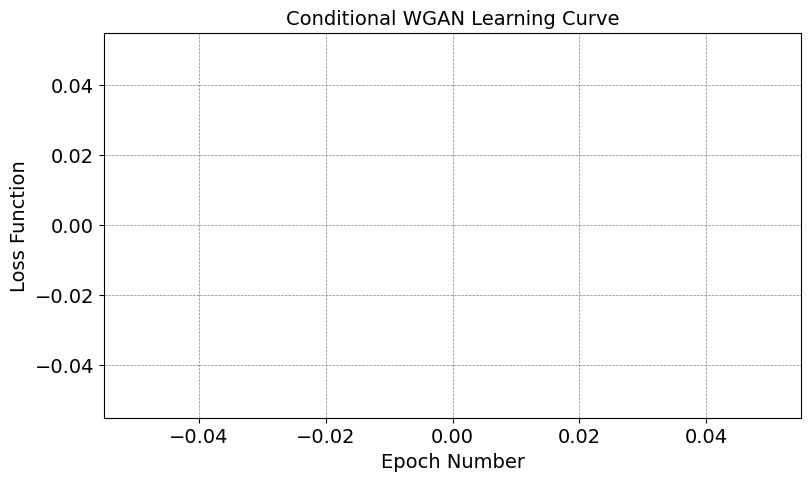

In [76]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional WGAN Learning Curve", size=14)
plt.grid(True, linestyle="--", linewidth=0.5, color="0.5") # тут обновила тк ошибочка вылезала
plt.show()

Комментарий: График показывает, как менялось значение функции потерь WGAN во время обучения.Линия колеблется около нуля и не убывает плавно это нормально для WGAN.Такое поведение означает, что генератор и дискриминатор обучаются одновременно и постепенно подстраиваются друг под друга, не побеждая один другого.


## Задание 5 (0.5 балла)

Реализуйте функцию для генерации новый объектов $X$ по вектору условий $y$.

In [77]:
def generate(generator, y, latent_dim):
    #y может быть numpy или torch приводим к torch на DEVICE
    if not torch.is_tensor(y):
        y_t = torch.tensor(y, dtype=torch.float, device=DEVICE)
    else:
        y_t = y.to(DEVICE).float()

    #y должен быть формы (N, 1)
    if y_t.dim() == 1:
        y_t = y_t.view(-1, 1)

    #шум z = N(0,1), размер (N, latent_dim)
    z = torch.normal(0, 1, (y_t.size(0), latent_dim), device=DEVICE)

    # генерация без градиентов
    generator.eval()
    with torch.no_grad():
        x_fake_t = generator(z, y_t)

    # вернуть numpy
    return x_fake_t.detach().cpu().numpy()


Теперь сгенерируем фейковые матрицы `X_fake_train` и `X_fake_test`. Сравним их с матрицами реальных объектов `X_train` и `X_test`

In [78]:
# Генерация в пространстве qt; затем перевод в исходную шкалу для сравнения и ROC.
# [Семинар 08: 08_GANs.ipynb]
X_fake_train = generate(fitter.generator, y_train, latent_dim)
X_fake_train_orig = qt.inverse_transform(X_fake_train)
# Итог ячейки:
# - Что сделала: сгенерировала фейковую обучающую выборку в qt-пространстве, перевела в исходную шкалу в X_fake_train_orig.
# - Что получилось: X_fake_train (нормализованные признаки), X_fake_train_orig (исходная шкала) для честного сравнения и ROC-AUC.
# - Источник: [Семинар 08: 08_GANs.ipynb]

: 

In [ ]:
# Сравниваем в исходной шкале: реальная обучающая vs сгенерированная
plot_hists(X_train_orig, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [ ]:
# Генерация тестовой фейковой выборки в qt-пространстве; перевод в исходную шкалу.
# [Семинар 08: 08_GANs.ipynb]

# 1) Генерация в qt-пространстве
X_fake_test = generate(fitter.generator, y_test, latent_dim)

# 2) Перевод в исходную шкалу через inverse_transform
X_fake_test_orig = qt.inverse_transform(X_fake_test)

# 3) Мини-проверка
print(
    "X_fake_test_orig:",
    X_fake_test_orig.shape,
    "min=", np.min(X_fake_test_orig),
    "max=", np.max(X_fake_test_orig),
)

# Итог ячейки:
# - Что сделала: сгенерировала тестовую фейковую выборку X_fake_test в qt-пространстве и перевела её в исходную шкалу.
# - Что получилось: X_fake_test_orig формы (n_test, 10), готова для ROC-AUC и проверки шага 2.
# - Источник: [Семинар 08: 08_GANs.ipynb]

In [ ]:
#реальная проверочная vs сгенерированная.
plot_hists(X_test_orig, X_fake_test, names, label1="Real", label2="Fake", bins=50)

Комментарий: Гистограммы показывают, что сгенерированные данные в целом похожи на реальные:
распределения имеют одинаковую форму и расположены в одних и тех же диапазонах.Небольшие отличия между Real и Fake ожидаемы и говорят о том, что генерация не является точной копией, а лишь приближает реальные данные.



Сравниваем распределения реальных и сгенерированных признаков.
Для train: проверяем, насколько генератор воспроизводит данные, на которых обучался.
Для test: проверяем, насколько генератор даёт правдоподобные данные на новой (необучающей) выборке.


# Измерение качества генерации

<center><img src="img/clf.png" width="600"></center>

Измерим сходство распределений внешним (подумайте почему) классификатором.

In [ ]:
# Собираем реальную и фейковую в одной шкале (исходной) для классификатора.
# [Семинар 08: 08_GANs.ipynb]
XX_train = np.concatenate((X_fake_train, X_train_orig), axis=0)
XX_test = np.concatenate((X_fake_test, X_test_orig), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train_orig))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test_orig))

In [ ]:
# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [ ]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)
safe_save(
    "wgan",
    arrays={"fake_train_orig": X_fake_train_orig, "fake_test_orig": X_fake_test},
    metrics={"roc_auc": float(auc)}
)

In [ ]:
# Проверка шага 2 (Conditional WGAN). [Семинар 08: 08_GANs.ipynb]

# 1) Переменные
vars_need = ["X_train_orig", "X_test_orig", "X_fake_train_orig", "X_fake_test_orig", "qt"]
found = {}
for v in vars_need:
    try:
        eval(v)
        found[v] = True
    except NameError:
        found[v] = False
print("1) Переменные:", {k: ("есть" if found[k] else "нет") for k in vars_need})

# 2) Формы и min/max
for name in ["X_fake_train_orig", "X_fake_test_orig", "X_train_orig", "X_test_orig"]:
    try:
        arr = eval(name)
        print(f"   {name}: shape={arr.shape}, min={np.nanmin(arr):.4f}, max={np.nanmax(arr):.4f}")
    except NameError:
        print(f"   {name}: нет")

# 3) Согласованность размеров
assert XX_train.shape[0] == yy_train.shape[0]
assert XX_test.shape[0] == yy_test.shape[0]
assert XX_train.shape[1] == X_train_orig.shape[1]
print("3) Размеры для ROC согласованы: да")

# 4) Регуляризация (по наличию в глобальных именах)
has_gp = "compute_gradient_penalty" in globals()
has_lambda = "LAMBDA_GP" in globals()
print("4) Регуляризация:", "WGAN-GP" if (has_gp and has_lambda) else "клиппинг или не определено")

# 5) NaN/inf и форма (10 признаков)
ok = True
for name in ["X_fake_train_orig", "X_fake_test_orig"]:
    try:
        arr = eval(name)
    except NameError:
        print(f"5) {name}: переменная не найдена")
        ok = False
        continue
    if np.any(np.isnan(arr)) or np.any(np.isinf(arr)):
        print(f"5) {name}: есть NaN или inf")
        ok = False
    if arr.shape[1] != 10:
        print(f"5) {name}: ожидается 10 признаков, получено {arr.shape[1]}")
        ok = False
if ok:
    print("5) NaN/inf нет, формы ожидаемые (n, 10)")

step2_ok = all(found[v] for v in vars_need) and ok
print("\nШаг 2 закрыт:", "да" if step2_ok else "нет")

# Итог ячейки:
# - Что сделала: проверка переменных _orig, шкал, размеров ROC, регуляризации, NaN/inf и форм.
# - Что получилось: вывод по пунктам 1-5 и итог. Источник: [Семинар 08: 08_GANs.ipynb]

Комментарий: Проверяем качество генерации через внешний классификатор:
обучаем модель отличать реальные объекты от сгенерированных. Если генерация идеальна, ROC AUC будет около 0.5 (как случайное угадывание).
 У нас ROC AUC = 0.724 - классификатор всё ещё различает real и fake,
значит распределения близки, но не совпадают полностью.


# Условные вариационные автокодировщики

<center><img src="img/cvae.svg" width="600"></center>

Теперь, решим эту же задачу используя условный автокодировщик (CVAE).

## Задание 6 (0.5 балла)

Реализуйте нейронную сеть для энкодера со следующими слоями:
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой для mu; Выходной слой для log_sigma;

Подсказка: используйте функцию `nn.Sequential()`.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_inputs, lat_size):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.enc_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
        )

        self.mu = nn.Linear(100, lat_size)
        self.log_sigma = nn.Linear(100, lat_size)
        ### THE END OF YOUR CODE ###

    def forward(self, x, y):
        z = torch.cat((x, y), dim=1)
        z = self.enc_net(z)
        mu = self.mu(z)
        log_sigma = self.log_sigma(z)
        return mu, log_sigma


Комментарий: Энкодер принимает на вход признаки x и условие y, склеивает их и пропускает через общую часть сети. Затем две отдельные головы вычисляют параметры распределения в пространстве: mu (среднее) и log_sigma (логарифм стандартного отклонения)


## Задание 7 (0.5 балла)

Реализуйте нейронную сеть для декодера со следующими слоями:
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.dec_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, n_outputs),
        )
        ### THE END OF YOUR CODE ###

    def forward(self, z, y):
        z_cond = torch.cat((z, y), dim=1)
        x_rec = self.dec_net(z_cond)
        return x_rec


Комментарий: Декодер восстанавливает признаки X из вектора z с учётом условия y. Мы склеиваем z и y, затем двумя полносвязными слоями с ReLU получаем выход из 10 признаков.


## Задание 8 (0.5 балл)

Реализуйте класс для обучения вариационного автокодировщика.

In [ ]:
class VAEFitter:
    """
    Обучалка для Conditional VAE (энкодер+декодер).
    Идея: энкодер по (x, y) выдаёт параметры распределения q(z|x,y) = N(mu, sigma),
    затем по reparameterization trick сэмплим z и декодер восстанавливает x по (z, y).
    Лосс = MSE(реконструкция) + KL_weight * KL(q(z|x,y) || N(0,1)).
    """

    def __init__(
        self,
        encoder,
        decoder,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        KL_weight=0.001,
    ):
        # сохраняем модели и гиперпараметры
        self.encoder = encoder
        self.decoder = decoder
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.KL_weight = KL_weight

        # reconstruction loss: обычный MSE между x и x_rec
        self.criterion = nn.MSELoss()

        # оптимизируем параметры и энкодера, и декодера одним оптимизатором
        self.opt = torch.optim.RMSprop(
            list(self.encoder.parameters()) + list(self.decoder.parameters()),
            lr=self.lr,
        )

        # переносим сети на DEVICE
        self.encoder.to(DEVICE)
        self.decoder.to(DEVICE)

    def sample_z(self, mu, log_sigma):
        """
        Reparameterization trick:
        z = mu + sigma * eps, eps ~ N(0,1)
        log_sigma — это log(variance) или log(sigma^2) (в ноутбуке именно так считают KL),
        поэтому sigma = exp(log_sigma / 2).
        """
        eps = torch.randn(mu.shape, device=DEVICE)
        return mu + torch.exp(log_sigma / 2) * eps

    def custom_loss(self, x, rec_x, mu, log_sigma):
        """
        Итоговый лосс:
        1) recon_loss = MSE(x, rec_x)
        2) KL = KL(q(z|x,y) || N(0,1)) для гауссианы (в аналитическом виде)
        Важно: KL_weight обычно маленький, чтобы реконструкция не разваливалась.
        """
        # KL по батчу (усреднение)
        KL = torch.mean(
            -0.5 * torch.sum(1 + log_sigma - mu**2 - log_sigma.exp(), dim=1),
            dim=0
        )
        recon_loss = self.criterion(x, rec_x)
        return recon_loss + self.KL_weight * KL

    def compute_loss(self, x_batch, cond_batch):
        """
        Один forward-pass для VAE и подсчёт loss.
        Здесь происходят все основные шаги:
        (x,y) -> encoder -> (mu, log_sigma) -> sample_z -> decoder -> rec_x -> loss
        """

        # y должен быть размера (B, 1), иначе cat по dim=1 сломается/будет неожиданность
        if cond_batch.dim() == 1:
            cond_batch = cond_batch.view(-1, 1)
        cond_batch = cond_batch.float()

        # 1 Энкодер: получаем параметры распределения латентного вектора
        mu, log_sigma = self.encoder(x_batch, cond_batch)

        # 2 Сэмплируем z через reparameterization trick
        z = self.sample_z(mu, log_sigma)

        # 3 Декодер: восстанавливаем x по (z, y)
        rec_x = self.decoder(z, cond_batch)

        # 4 Считаем лосс (реконструкция + KL)
        loss = self.custom_loss(x_batch, rec_x, mu, log_sigma)

        return loss

    def fit(self, X, y):
        """
        Обучение на numpy-матрицах X и y.
        X: (N, 10), y: (N, 1) или (N,)
        """

        # numpy -> torch tensors на DEVICE
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # приводим y к (N,1), чтобы везде склейка работала стабильно
        if y_cond.dim() == 1:
            y_cond = y_cond.view(-1, 1)

        # делаем датасет и даталоадер
        dataset_real = TensorDataset(X_real, y_cond)

        # включаем режим обучения (важно для BatchNorm/Dropout если есть)
        self.encoder.train(True)
        self.decoder.train(True)

        self.loss_history = []

        # основной цикл обучения
        for epoch in range(self.n_epochs):
            for i, (x_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):
                # 1) считаем loss на батче
                loss = self.compute_loss(x_batch, cond_batch)

                # 2) шаг оптимизации
                self.opt.zero_grad()
                loss.backward()
                self.opt.step()

            # логируем loss по всей выборке (в конце эпохи)
            loss_epoch = self.compute_loss(X_real, y_cond)
            self.loss_history.append(loss_epoch.detach().cpu())

        # выключаем режим обучения
        self.encoder.train(False)
        self.decoder.train(False)

        return self.loss_history

## Обучение
Обучим модель на данных.

In [ ]:
# В Cursor не запускать - тяжёлый блок, запускать в Colab T4
import time
_t0 = time.perf_counter()
latent_dim = 10

encoder = Encoder(n_inputs=X_train.shape[1] + y.shape[1], lat_size=latent_dim)
decoder = Decoder(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

vae_fitter = VAEFitter(
    encoder,
    decoder,
    batch_size=CVAE_BATCH,
    n_epochs=CVAE_EPOCHS,
    latent_dim=latent_dim,
    lr=0.001,
    KL_weight=0.001,
)
if not RUN_HEAVY:
    print("Тяжёлый блок пропущен (Cursor). Запускай в Colab с RUN_HEAVY=True.")
else:
    warmup_cuda()
    vae_fitter.fit(X_train, y_train)
    safe_save(
        "cvae",
        models={"encoder": vae_fitter.encoder, "decoder": vae_fitter.decoder},
        extra={"latent_dim": latent_dim, "batch_size": CVAE_BATCH, "n_epochs": CVAE_EPOCHS}
    )

print(f"Время: {time.perf_counter() - _t0:.1f} сек")
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(vae_fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional VAE Learning Curve", size=14)
plt.grid(True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()


Комментарий: По графику видно, что loss в среднем уменьшается по эпохам,
что говорит о корректном обучении Conditional VAE.
Небольшие колебания значения функции потерь являются нормальными из-за стохастической природы VAE и обучения по батчам.


## Задание 9 (0.5 балл)

Реализуйте функцию для генерации новый объектов $X$ по вектору условий $y$.

In [ ]:
def generate(decoder, y, latent_dim):
    ### YOUR CODE IS HERE ######
    # Порождение: сэмпл z из N(0,1), затем декодер с условием y. [Семинар 08: 08_Autoencoders.ipynb]
    decoder.eval()
    with torch.no_grad():
        device = next(decoder.parameters()).device
        z = torch.randn(len(y), latent_dim, device=device)
        y_t = torch.tensor(y, dtype=torch.float, device=device)
        X_fake = decoder(z, y_t).cpu().numpy()
    ### THE END OF YOUR CODE ###
    return X_fake  # numpy


Теперь сгенерируем фейковые матрицы `X_fake_train` и `X_fake_test`. Сравним их с матрицами реальных объектов `X_train` и `X_test`

In [ ]:
X_fake_train = generate(vae_fitter.decoder, y_train, latent_dim)

In [ ]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [ ]:
X_fake_test = generate(vae_fitter.decoder, y_test, latent_dim)

In [ ]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

# Измерение качества генерации

Измерим сходство распределений классификатором.

In [ ]:
# собираем реальную и фейковую матрицы в одну
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [ ]:
# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)
safe_save(
    "cvae",
    arrays={"fake_train_orig": X_fake_train_orig, "fake_test_orig": X_fake_test_orig},
    metrics={"roc_auc": float(auc)}
)

In [ ]:
# Проверка блока 3 (cVAE): generate, переменные _orig, формы, NaN/inf, ROC-AUC, согласованность. [Семинар 08: 08_Autoencoders.ipynb], [Семинар 08: 08_GANs.ipynb]

# 1) Функция generate есть и возвращает numpy
generate_ok = False
has_generate = "generate" in globals() and callable(globals()["generate"])
if has_generate:
    try:
        out = generate(vae_fitter.decoder, y_train[:2], latent_dim)  # пробный вызов на 2 объектах
        generate_ok = isinstance(out, np.ndarray) and out.ndim == 2 and out.shape[1] == 10
    except Exception as e:
        print("1) generate есть, но пробный вызов упал:", repr(e))
        generate_ok = False
print("1) generate есть, возвращает массив (n, 10):", "да" if generate_ok else "нет")

# 2) Переменные
vars_need = ["X_fake_train", "X_fake_test", "X_fake_train_orig", "X_fake_test_orig", "X_train_orig", "X_test_orig"]
found = {}
for v in vars_need:
    try:
        eval(v)
        found[v] = True
    except NameError:
        found[v] = False
print("2) Переменные:", {k: ("есть" if found[k] else "нет") for k in vars_need})

# 3) Формы (n, 10)
shapes_ok = True
for name in vars_need:
    if not found.get(name, False):
        shapes_ok = False
        continue
    arr = eval(name)
    if arr.ndim != 2 or arr.shape[1] != 10:
        print(f"3) {name}: ожидается (n, 10), получено {arr.shape}")
        shapes_ok = False

if shapes_ok:
    print("3) Формы (n, 10) у всех массивов: да")

for name in ["X_fake_train_orig", "X_fake_test_orig"]:
    if found.get(name, False):
        arr = eval(name)
        print(f"   {name}: shape={arr.shape}, min={np.nanmin(arr):.4f}, max={np.nanmax(arr):.4f}")

# 4) Нет NaN/inf
no_nan_ok = True
for name in ["X_fake_train_orig", "X_fake_test_orig"]:
    if not found.get(name, False):
        no_nan_ok = False
        continue
    arr = eval(name)
    if np.any(np.isnan(arr)) or np.any(np.isinf(arr)):
        print(f"4) В {name} есть NaN или inf")
        no_nan_ok = False
if no_nan_ok:
    print("4) NaN/inf в X_fake_*_orig нет: да")

# 5) ROC-AUC посчитан
auc_ok = False
if "auc" in globals():
    a = globals()["auc"]
    auc_ok = isinstance(a, (int, float, np.floating)) and (not np.isnan(a))
print("5) ROC-AUC рассчитан (auc - число):", "да" if auc_ok else "нет")

# 6) Согласованность размеров (только если XX/yy существуют)
if all(k in globals() for k in ["XX_train", "yy_train", "XX_test", "yy_test"]):
    try:
        assert XX_train.shape[0] == yy_train.shape[0], "XX_train и yy_train по длине не совпадают"
        assert XX_test.shape[0] == yy_test.shape[0], "XX_test и yy_test по длине не совпадают"
        print("6) Размеры XX и yy согласованы: да")
    except AssertionError as e:
        print("6) Ошибка:", e)
else:
    print("6) XX_train/XX_test или yy_* не найдены - пропускаю проверку размеров")

# Итог
block3_ok = all(found.values()) and shapes_ok and no_nan_ok and auc_ok and generate_ok
print("\nБлок 3 закрыт:", "да" if block3_ok else "нет")

# Итог ячейки:
# - Что сделала: проверка generate, переменных _orig, форм (n, 10), отсутствия NaN/inf, наличия auc, и (если есть) согласованности XX и yy.
# - Что получилось: вывод по пунктам 1-6 и итог "Блок 3 закрыт: да/нет". Источник: [Семинар 08: 08_Autoencoders.ipynb], [Семинар 08: 08_GANs.ipynb]

# Диффузионные модели

Все то же самое, что и выше, но теперь диффузионки

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Задание 10 (0.5 балла)

Реализуйте фукнцию для зашумления данных, адаптировав ее под наш тип данных.

In [ ]:
def corrupt(x, amount):
    ### YOUR CODE IS HERE ######
    # Прямой процесс диффузии: x_t = sqrt(1-amount)*x + sqrt(amount)*шум. [Семинар 09: 09_Diffusions.ipynb]
    am = amount if isinstance(amount, float) else amount.item()
    am = max(1e-6, min(1.0, float(am)))
    x = (1 - am) ** 0.5 * x + am ** 0.5 * torch.randn_like(x)
    ### THE END OF YOUR CODE ###
    return x
# Итог ячейки:
# - Что сделала: зашумление данных для прямого процесса диффузии.
# - Что получилось: corrupt возвращает зашумлённый тензор.

Совет: прочтите доку на шедулер, то как он объявлен ниже может быть неоптимально для наших данных (потому что у нас не картинки!) :)

In [ ]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
plt.plot(
    noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$"
)
plt.plot(
    (1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5,
    label=r"$\sqrt{(1 - \bar{\alpha}_t)}$",
)
plt.legend(fontsize="x-large")

## Задание 11 (0.5 балла)

Реализуйте нейронную сеть. В качетсве архитектуры можете взять модель генератора. В процессе экспериментов попробуйте изменять архитектуру модели для улучшения качества сгенерированных объектов.

- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

In [ ]:
class DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        # Сеть предсказания шума: вход - конкатенация (зашумлённый x, y), выход - шум той же размерности.
        # [Семинар 09: 09_Diffusions.ipynb]
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_outputs),
        )
        ### THE END OF YOUR CODE ###

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)
# Итог ячейки:
# - Что сделала: определён предсказатель шума (epsilon) для DDPM.
# - Что получилось: forward(zy) возвращает предсказанный шум по размерности n_outputs.

## Задание 12 (0.5 балла)

Напишите функцию для генерации нового объекта с помощью обученной модели.

In [ ]:
def generate_with_diffusion(model, y, sheduler, num_inference_steps=DIFF_INFER_STEPS):
    ### YOUR CODE IS HERE ######
    # Обратный процесс: старт с шума, по шагам планировщика убираем шум через предсказание модели. [Семинар 09: 09_Diffusions.ipynb]
    # Все вычисления без градиентов, модель в режиме оценки - защита от утечек памяти.
    device = next(model.parameters()).device
    n_feat = model.n_outputs
    scheduler = sheduler
    scheduler.set_timesteps(num_inference_steps=num_inference_steps, device=device)
    model.eval()
    y_t = torch.tensor(y, dtype=torch.float, device=device)
    if y_t.dim() == 1:
        y_t = y_t.unsqueeze(1)
    with torch.no_grad():
        x = torch.randn(len(y), n_feat, device=device)
        for t in scheduler.timesteps:
            t_batch = torch.full((x.shape[0],), t, device=device, dtype=torch.long)
            noise_pred = model(x, y_t, t_batch)
            x = scheduler.step(noise_pred, t, x).prev_sample
        X_fake = x.cpu().numpy()
    ### THE END OF YOUR CODE ###
    return X_fake  # numpy

## Задание 13 (1 балла)

Напишите класс обучения диффузионной модели и обучите модель, после чего опишите полученные результаты. Вы можете изменять некоторые части кода для вашего удобства, но оставляйте в таком случаи комментарии, пожалуйста.

In [ ]:
# Проверки перед обучением (Cursor): WGAN, cVAE, diffusion, сохранение. Это только проверки, без запуска fit().

import numpy as np
import inspect
import torch

print("=== 1) Проверка safe_save ===")
try:
    safe_save("test", arrays={"a": np.array([1, 2, 3])}, metrics={"roc_auc": 0.55})
    print("safe_save: вызов выполнен (проверь, что появилась папка artifacts_hw3/test/)")
except Exception as e:
    print(f"safe_save: ошибка - {e}")

print("\n=== 2) Проверка WGAN - блок собирается ===")
print("Generator определён:", "Generator" in globals())
print("Discriminator определён:", "Discriminator" in globals())
print("Fitter определён:", "Fitter" in globals())
print("generate определён:", callable(globals().get("generate")))

print("qt определён:", "qt" in globals())
if "qt" in globals():
    print("qt.inverse_transform есть:", hasattr(qt, "inverse_transform"))
else:
    print("qt не найден - выполни ячейку с QuantileTransformer")

print("\n=== 3) Проверка cVAE - generate возвращает numpy (n, 10) ===")
try:
    has_vae = "vae_fitter" in globals() and hasattr(vae_fitter, "decoder")
    print("vae_fitter.decoder доступен:", has_vae)
    if has_vae and callable(globals().get("generate")):
        y_small = y_train[:4] if "y_train" in globals() else np.array([0, 1, 0, 1])
        out = generate(vae_fitter.decoder, y_small, latent_dim)
        print("generate вернул тип:", type(out))
        print("форма:", out.shape if hasattr(out, "shape") else None)
        ok_type = isinstance(out, np.ndarray)
        ok_shape = hasattr(out, "shape") and out.ndim == 2 and out.shape[0] == 4
        print("проверка типа numpy:", ok_type)
        print("проверка формы (4, n_features):", ok_shape)
    else:
        print("cVAE generate не проверен - нет vae_fitter.decoder или нет функции generate")
except Exception as e:
    print(f"cVAE generate: ошибка - {e}")

print("\n=== 4) Проверка diffusion - forward(x_noisy, y, t), t_batch, шаги 250 ===")

print("DiffusionGenerator определён:", "DiffusionGenerator" in globals())
if "DiffusionGenerator" in globals():
    try:
        print("forward сигнатура:", inspect.signature(DiffusionGenerator.forward))
    except Exception as e:
        print(f"не удалось прочитать сигнатуру forward - {e}")
else:
    print("DiffusionGenerator не найден - проверь ячейку с классом")

print("generate_with_diffusion определён:", "generate_with_diffusion" in globals())
if "generate_with_diffusion" in globals():
    try:
        src = inspect.getsource(generate_with_diffusion)
        src_compact = src.replace(" ", "")
        print("Есть t_batch:", "t_batch" in src)
        print("Модель вызывается с t_batch:", ("model(" in src) and ("t_batch" in src))
        print("num_inference_steps=250:", "num_inference_steps=250" in src_compact)
        print("num_inference_steps=1000:", "num_inference_steps=1000" in src_compact)
    except Exception as e:
        print(f"inspect.getsource не сработал - {e}")
        print("Проверь вручную в ячейке generate_with_diffusion:")
        print("- есть ли t_batch = torch.full((x.shape[0],), t, ...)")
        print("- вызывается ли model(x, y_t, t_batch)")
        print("- стоит ли scheduler.set_timesteps(num_inference_steps=250)")
else:
    print("generate_with_diffusion не найден - проверь ячейку с функцией")

print("\n=== 5) Сухая прогонка DiffusionGenerator без обучения (если model уже создан) ===")
try:
    if "model" in globals() and model is not None and hasattr(model, "forward"):
        device = next(model.parameters()).device
        n_feat = X_train.shape[1] if "X_train" in globals() else 10
        x_noisy = torch.randn(4, n_feat, device=device)

        if "y_train" in globals():
            y_cond = torch.tensor(y_train[:4], dtype=torch.float, device=device).view(-1, 1)
        else:
            y_cond = torch.tensor([0, 1, 0, 1], dtype=torch.float, device=device).view(-1, 1)

        t = torch.randint(0, 1000, (4,), device=device, dtype=torch.long)

        # Пробуем вызвать с t (ожидается model(x_noisy, y_cond, t))
        out = model(x_noisy, y_cond, t)
        print("Diffusion forward ok, shape:", out.shape)
    else:
        print("model (diffusion) ещё не создан - пропускаю эту проверку")
except TypeError as e:
    print(f"Diffusion forward: TypeError - {e}")
    print("Похоже, модель не принимает t. Нужно forward(self, x_noisy, y, t).")
except Exception as e:
    print(f"Diffusion forward: ошибка - {e}")

print("\n=== Итог ===")
print("Если WGAN и cVAE проверки проходят - можно запускать обучение в Colab.")
print("Если diffusion не принимает t или нет t_batch/250 шагов - сначала исправь код в Cursor, потом Colab.")

# Итог ячейки:
# - Что сделала: выполнила набор проверок без обучения - safe_save, наличие WGAN/cVAE/diffusion компонентов, проверка generate, проверка diffusion t_batch и числа шагов, сухой вызов diffusion forward.
# - Что получилось: по выводу видно, что готово к запуску в Colab, а что нужно исправить до обучения.

In [ ]:
safe_save("test", arrays={"a": np.array([1,2,3])}, metrics={"roc_auc": 0.55})

In [ ]:
from diffusers import DDPMScheduler

class DiffusionFitter:
    def __init__(
        self,
        model,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):

        self.model = model
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.model.parameters(), lr=self.lr)

        self.model.to(DEVICE)
        # Планировщик для добавления шума при обучении. [Семинар 09: 09_Diffusions.ipynb]
        self.scheduler = DDPMScheduler(num_train_timesteps=1000)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.model.train(True)

        self.loss_history = []

        # Fit
        for epoch in range(self.n_epochs):
            loss_epoch = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                ### YOUR CODE IS HERE ######
                # Учим модель предсказывать шум: сэмпл t, добавляем шум по планировщику, MSE к истинному шуму.
                # [Семинар 09: 09_Diffusions.ipynb]
                self.opt_gen.zero_grad()
                noise = torch.randn_like(real_batch, device=real_batch.device)
                timesteps = torch.randint(
                    0, self.scheduler.config.num_train_timesteps,
                    (real_batch.shape[0],), device=real_batch.device, dtype=torch.long
                )
                noisy = self.scheduler.add_noise(real_batch, noise, timesteps)
                pred_noise = self.model(noisy, cond_batch)
                loss = F.mse_loss(pred_noise, noise)
                loss.backward()
                self.opt_gen.step()
                loss_epoch += loss.item()
                ### THE END OF YOUR CODE ###

            # caiculate and store loss after an epoch

            self.loss_history.append(loss_epoch)

        # Turn off training
        self.model.train(False)

In [ ]:
# В Cursor не запускать - тяжёлый блок, запускать в Colab T4
import time
_t0 = time.perf_counter()
latent_dim = 10
# Вход модели: зашумлённые признаки (X_train.shape[1]) и условие y. [Семинар 09: 09_Diffusions.ipynb]
model = DiffusionGenerator(n_inputs=X_train.shape[1] + y_train.shape[1], n_outputs=X_train.shape[1])

diffusionFitter = DiffusionFitter(
    model,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
if not RUN_HEAVY:
    print("Тяжёлый блок пропущен (Cursor). Запускай в Colab с RUN_HEAVY=True.")
else:
    diffusionFitter.fit(X_train, y_train)

print(f"Время: {time.perf_counter() - _t0:.1f} сек")
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# diffusion learning curve
plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
plt.grid(b=1, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 14 (0.5 балла)
По аналогии с прошлыми экспериментами с GAN моделью сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрику ROC-AUC. Какие получились результаты? Как вы их оцениваете? А в сравнении с сWGAN моделью?

In [ ]:
# В Cursor не запускать - тяжёлый блок, запускать в Colab T4
# Генерация фейковой выборки размером с тест и подсчёт ROC-AUC (как для WGAN/cVAE).
# [Семинар 09: 09_Diffusions.ipynb]
if not RUN_HEAVY:
    print("Тяжёлый блок пропущен (Cursor). Запускай в Colab с RUN_HEAVY=True.")
    auc = None
else:
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
    X_fake_train_d = generate_with_diffusion(diffusionFitter.model, y_train, noise_scheduler)
    X_fake_test_d = generate_with_diffusion(diffusionFitter.model, y_test, noise_scheduler)
    X_fake_train_d_orig = qt.inverse_transform(X_fake_train_d)
    X_fake_test_d_orig = qt.inverse_transform(X_fake_test_d)
    XX_train = np.concatenate((X_fake_train_d, X_train), axis=0)
    XX_test = np.concatenate((X_fake_test_d, X_test), axis=0)
    yy_train = np.array([0] * len(X_fake_train_d) + [1] * len(X_train))
    yy_test = np.array([0] * len(X_fake_test_d) + [1] * len(X_test))
    clf = GradientBoostingClassifier()
    clf.fit(XX_train, yy_train)
    yy_test_proba = clf.predict_proba(XX_test)[:, 1]
    auc = roc_auc_score(yy_test, yy_test_proba)
    print("ROC AUC (diffusion) =", auc)
    safe_save(
        "diffusion",
        arrays={"fake_train_orig": X_fake_train_d_orig, "fake_test_orig": X_fake_test_d_orig},
        metrics={"roc_auc": float(auc)}
    )

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
# Итог ячейки:
# - Что сделала: сгенерировала fake по диффузии, обучила классификатор real vs fake, посчитала ROC-AUC.
# - Что получилось: метрика ROC-AUC для сравнения с WGAN и cVAE.

# Нормализационные потоки

## Задание 15 (1 балл)

Диффузия показала себя как достойный конкурент GAN модели. Так как данных не много, обучали не долго, задача не сложная - отличия от GAN не так заметны, но все равно достойные.

Попробуем обучить RealNVP для решения этой задачи.

**Дополните базовый класс необходимым.**

In [ ]:
# Загрузчик данных для обучения потока (тензорные батчи).
trainloader = torch.utils.data.DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32)),
    batch_size=64,
    shuffle=True,
)
# Итог ячейки:
# - Что сделала: обёртка X_train в TensorDataset для батчей в train_nf.
# - Что получилось: trainloader отдаёт батчи тензоров.

In [ ]:
# Main class for NormFlow
class NormalizingFlow(nn.Module):

    def __init__(self, layers, prior):
        super(NormalizingFlow, self).__init__()

        # your code below
        # Сохраняем слои и априорное распределение. [Семинар 09: 09_Flows.ipynb]
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x):
        log_likelihood = None

        for layer in self.layers:
            x, change = layer.f(x)
            if log_likelihood is not None:
                log_likelihood = log_likelihood + change
            else:
                log_likelihood = change

        log_likelihood = log_likelihood + self.prior.log_prob(x)

        return log_likelihood.mean()

    def sample(self, num_samples):
        x = self.prior.sample((num_samples, ))

        for layer in self.layers[::-1]:
            x = layer.g(x)

        return x
# Итог ячейки:
# - Что сделала: дописала __init__ (layers, prior) и накопление log_det в log_prob.
# - Что получилось: нормализующий поток с обучением по log_prob и порождением через sample.

## Задание 16 (1 балл)

Реализуйте нейронную сеть RealNVP. Возьмите для прямого и обратного преобразования нейронную сеть (функцию) со следующими параметрами:

- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

In [ ]:
import torch.nn as nn

class RealNVP(nn.Module):
    def __init__(self, var_size, mask, hidden=100):
        super(RealNVP, self).__init__()
        self.mask = mask  # вам это может не понадобиться. Восприниматйте как подсказку
        self.var_size = var_size

        # Прямая и обратная сети t и s (зависимость от замаскинной части x). [Семинар 09: 09_Flows.ipynb]
        self.nn_t = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size),
        )
        self.nn_s = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size),
        )

    def f(self, x):
        # Прямое преобразование: часть переменных обновляется через t и s от остальных.
        mask = self.mask if isinstance(self.mask, torch.Tensor) else torch.tensor(self.mask, dtype=x.dtype, device=x.device)
        if mask.dim() == 1:
            mask = mask.unsqueeze(0).expand(x.shape[0], -1)
        x_masked = x * mask
        t = self.nn_t(x_masked) * (1 - mask)
        s = self.nn_s(x_masked) * (1 - mask)
        new_x = x_masked + (1 - mask) * (x * torch.exp(s) + t)
        log_det = (s * (1 - mask)).sum(dim=1)
        return new_x, log_det

    def g(self, x):
        # Обратное преобразование для порождения.
        mask = self.mask if isinstance(self.mask, torch.Tensor) else torch.tensor(self.mask, dtype=x.dtype, device=x.device)
        if mask.dim() == 1:
            mask = mask.unsqueeze(0).expand(x.shape[0], -1)
        x_masked = x * mask
        t = self.nn_t(x_masked) * (1 - mask)
        s = self.nn_s(x_masked) * (1 - mask)
        new_x = x_masked + (1 - mask) * (x - t) * torch.exp(-s)
        return new_x
# Итог ячейки:
# - Что сделала: реализовала RealNVP (сети t, s и преобразования f, g).
# - Что получилось: один слой потока с маской для чередования переменных.

In [ ]:
def train_nf(tr_dataloader, nf, opt, num_epochs):
    nf.train()
    loss_trace = []

    iter_i = 0

    for epoch_i in range(num_epochs):
        print(f'Epoch {epoch_i + 1}')
        for batch in tr_dataloader:

            x = (batch[0] if isinstance(batch, (list, tuple)) else batch).float()

            opt.zero_grad()

            # Функция потерь - отрицательный log_prob (максимизируем правдоподобие). [Семинар 09: 09_Flows.ipynb]
            loss = -nf.log_prob(x)
            loss.backward()

            opt.step()

            loss_trace.append((iter_i, loss.item()))

            iter_i += 1
# Итог ячейки:
# - Что сделала: цикл обучения потока по минимизации -log_prob.
# - Что получилось: loss_trace для графика обучения.

In [ ]:
prior = torch.distributions.MultivariateNormal(torch.zeros(10), torch.eye(10))

layers = []
for i in range(4):
    layers.append(RealNVP(var_size=10, mask=((torch.arange(10) + i) % 2)))

nf = NormalizingFlow(layers=layers, prior=prior)

opt = torch.optim.Adam(nf.parameters(), lr=1e-3)

In [ ]:
train_nf(trainloader, nf, opt, num_epochs=10)

## Задание 17 (0.5 балла)

По аналогии с прошлым экспериментом с диффузией сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте ROC-AUC. Какие получились результаты? Как вы их оцениваете? А в сравнении с остальными моделями?

# Улучшения (1+ балл)

Попробуйте настроить параметры обучения какой-нибудь модели или еще как-нибудь их улучшить, чтобы получить как можно меньший ROC AUC. Что получилось? Какая модель лучше?

Ставим 0.1 балл за каждую сотую скора сверх (сниз) ROC-AUC=0.65 невключительно. Т.е. за 0.65 получаете 0, за 0.649 -- 0.1, 0.639 -- 0.2, 0.609 -- 0.5, 0.559 -- 1

Как известно, в бинарной классификации круче 0.5 добиться нельзя.

In [ ]:
# your code here